In [21]:
from pathlib import Path
import logging
import time
import os
import numpy as np


from src.uq import UqDriverStageRun
from src.job_manager import LocalManager
from src.java_manager import JavaUqBepuStageRun
from src.rf_manager import RfManagerBepuRemote
from src.config import read_config_from_yaml

In [2]:
# auto-reload modules
%load_ext autoreload
%autoreload 2

# 1 Specify the path

In [3]:

SAMPLE_LIST = range(1)
INTERACTIVE_MODE = False

# 2 Read Config

In [4]:
CONFIG_PATH =  r'configs/tall3D_SS_BOT_BEPU_noStageRun.yaml'
config = read_config_from_yaml(CONFIG_PATH)

- path: 
  - `root`: simulation folder with inputs and outputs
  - `base_sim_filepath`: path to the .sim file
  - `ils_filepath`:  path ils file
  - `de_folderpath`: path to numerical uncertainty file
  - `bepu_input_path`: path input
  - `exe_filepath` (no need this in steady-sate): starccm+ will launch this external bash
  - `py_filepath` (no need this in steady-state): bash run this file

- job:
  - `slurm_filepath`: path to job scheduling (slurm) script 
  - `partition`, `time_for_nodes`, `n_nodes`, `n_cores`, `n_cores_for_computing`, `interative_mode`: the setting for job scheduling
  - `rerun`: overwrite if the case already exists

- java:
  - `java_filepath`: list. The files to be used in UQ process
  - `java_keywords`:  dictionary. Keys: the keywords in the java file that should be replaced. Values: the replacements.

- rf: contains most 
  - `target_quantity`: the column name of integral length scale in `ils.csv`
  - `k_l0`, `s_2`, `n_trunc`: the hyperparameters
  - `n_modes`: the number of down-sampled grf grids 
  - `model_error_on`: control if the GRF should contain information of model error 
  - `disc_error_on`:control if the GRF should contain information of numerical error  

# 3 Setup job manager 

In [5]:

path_config = {
    'root':config['path']['root'],
    'base_sim_filepath':config['path']['base_sim_filepath'],
    'exe_filepath':config['path']['exe_filepath'],
    'bepu_input_path':config['path']['bepu_input_path'],
    'ils_filepath':config['path']['ils_filepath']
}

In [6]:

# Set up job manager
job_manager = LocalManager(
    slurm_filepath = config['job']['slurm_filepath'],  
    partition=config['job']['partition'],
    time_for_nodes=config['job']['time_for_nodes'],
    n_nodes=config['job']['n_nodes'],
    n_cores=config['job']['n_cores'],
    n_cores_for_computing=config['job']['n_cores_for_computing'],
    interactive_mode = config['job']['interactive_mode'], 
    rerun = config['job']['rerun']
)

java_manager = JavaUqBepuStageRun(
    java_filepath = config['java']['java_filepath'],
    java_keywords = config['java']['java_keywords'],
)

rf_manager = RfManagerBepuRemote(
    root = config['path']['root'],
    de_folderpath =config['path']['de_folderpath'],
    ils_filepath=config['path']['ils_filepath'],
    py_filepath=config['path']['py_filepath'],
    target_quantity = config['rf']['target_quantity'],
    k_l0 =config['rf']['k_l0'],
    s_2 = config['rf']['s_2'],
    n_trunc = config['rf']['n_trunc'],
    n_modes = config['rf']['n_modes'],
    save_every_rf = config['rf']['save_every_rf'],
    model_error_on = config['rf']['model_error_on'],
    disc_error_on = config['rf']['disc_error_on']
)



# 4 Setup UQ driver

In [7]:

uq = UqDriverStageRun(
    path_config = path_config,
    rf_manager = rf_manager,
    job_manager = job_manager, 
    java_manager = java_manager

)

uq.setup()
uq.copy_config(CONFIG_PATH)

In [ ]:
for sample_id in SAMPLE_LIST:
    uq.init_sample_folder(sample_id, folder_suffix=None)
    uq.prepare_sample_files(sample_id)

/media/yw/Research/MIT-TP/scripts/test_case_tall3D/0/run_uqss_Tall3D_IE.java
/media/yw/Research/MIT-TP/scripts/test_case_tall3D/0/run_uqss_Tall3D_GRF.java


# 5 Inspect the GRF

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from src.grf_remote import MultiplierBepu, read_config

In [27]:
## Plotting functions
# Visualize the samples
from scipy.interpolate import griddata
def plot_cartesian(
    x, y, value, norm=None, 
    ax=None, 
    fig=None, cmap='bwr', 
    add_cbar=False, vmax=None, vmin=None, figsize=None, res=50, l=100):

    vmin = np.min(value) if vmin is None else vmin
    vmax = np.max(value) if vmax is None else vmax
    levels = np.linspace(vmin, vmax, l, endpoint=True)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    resolution = str(res)+'j'
    X,Y = np.mgrid[min(x):max(x):complex(resolution),   min(y):max(y):complex(resolution)]
    points = [[a,b] for a,b in zip(x,y)]
    Z = griddata(points, value, (X, Y), method='linear')

    cs = ax.contourf(X, Y, Z, 
            norm=norm,
            levels=levels, 
            extend='both',
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            alpha=0.8
            )
    return cs



def plot_midplane(
    x, y, z, value, norm=None, 
    ax=None, 
    fig=None, cmap='bwr', 
    add_cbar=False, vmax=None, vmin=None, figsize=None, res=50,l = 100):
        
    idx = np.where(abs(y-0)<1E-4)[0]
    # plot_cartesian(x, y, value, add_cbar=True, figsize=(3, 5))
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    cs = plot_cartesian(x=x[idx], y=z[idx], value=value[idx], ax=ax, fig=fig, cmap=cmap, add_cbar=add_cbar, vmax=vmax, vmin=vmin, figsize=figsize, norm=norm, res=res, l=l)
    if add_cbar:
        cbar = plt.colorbar(cs, ax=ax, pad=0.01, shrink=0.8)
    return 




/media/yw/Research/MIT-TP/scripts/driver/src/grf_remote.py:110: RuntimeWarning: invalid value encountered in multiply
  C = self.s_2/ g * np.sqrt(2) * r_l0 * scipy.special.kn(1, np.sqrt(2) * r_l0)


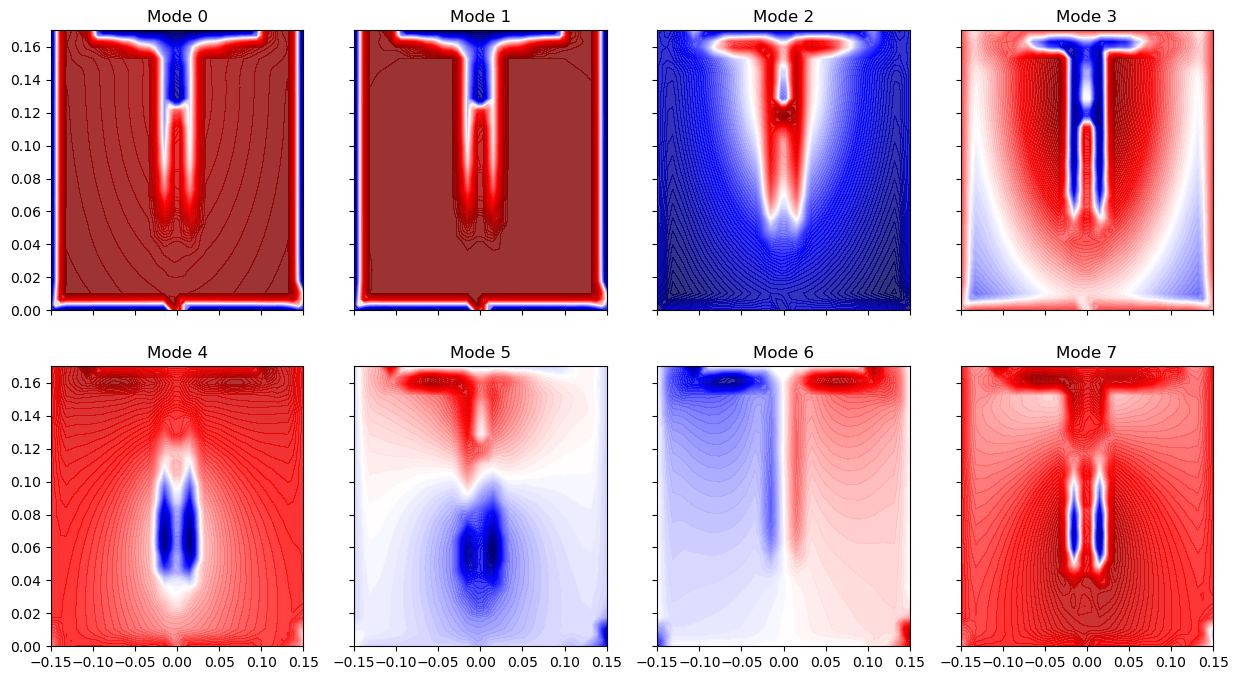

In [28]:
# Initialize the variables
case_folder = uq._case_folders.get(sample_id, uq.root /f'{sample_id}')
assert case_folder.exists(), f'Case folder not found at {case_folder}'

bepu_input_dict = read_config(case_folder / 'bepu_input_dict.json')
var_config = read_config(config_path = case_folder / 'rf_dict.json')
ils_filepath = case_folder / 'ils.csv'

target_quantity = var_config['target_quantity']
k_l0 = float(var_config['k_l0'])
s_2 = float(var_config['s_2'])
de_filepath = var_config['de_filepath']
n_trunc = int(var_config['n_trunc'])
model_error_on = var_config['model_error_on']
disc_error_on = var_config['disc_error_on']


# Initialize the MultiplierBepu class
m = MultiplierBepu(
    target_quantity = target_quantity,
    k_l0 = k_l0,
    s_2 = s_2,
    ils_filepath=ils_filepath, 
    de_filepath = de_filepath,
    bepu_input_dict=bepu_input_dict,
    model_error_on = model_error_on,
    disc_error_on = disc_error_on,
    save_to='temp')


# Compute the GRF covariance matrix
de_rv = m.get_de_rv()
m.compute_ils_de(de_rv)
m.compute_ils_me()
m.compute_ils_ie()
C = m.get_cov_matrix()

# Eigendecomposition of the covariance matrix
n_modes = len(C)
V, D, flags = np.linalg.svd(C)

# plot mode 
mode_idx = range(8)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(5*3, 2*4), sharex=True, sharey=True)

for mode_id in mode_idx:
    ax = axes[mode_id//4, mode_id%4]
    value = V[:, mode_id]
    plot_midplane(x=m.coord[:, 0], 
                  y=m.coord[:, 1], 
                  z=m.coord[:, 2], 
                  value=value, 
                  add_cbar=None,
                  ax=ax, 
                  fig=fig,
                  figsize=(3, 5), cmap='seismic',)
    ax.set_title(f'Mode {mode_id}')

